# 28: Polling / Survey Analysis — Chain, Argument, WaveSet

## What this shows
End-to-end survey analysis pipeline: respondent-level DataFrame → `Chain` cross-tab → `Argument` (headline + table + optional map) → multi-wave `WaveSet` comparison with trend / heatmap charts.

## Why it matters
This notebook is the canonical replacement for the deprecated `PollingAnalyzer` class (see ELE-2439). Instead of a bespoke analyzer, polling work now composes three small primitives:

| Primitive | Purpose | Module |
|---|---|---|
| `build_chain` | Cross-tab builder | `siege_utilities.survey.crosstab` |
| `chain_to_argument` | Chain → page-ready `Argument` | `siege_utilities.survey.render` |
| `WaveSet.compare_chain` | Longitudinal comparison across waves | `siege_utilities.survey.models` |

## Prereqs
```
pip install 'siege-utilities[survey,reporting]'
```
No external services — all data is synthesized in the notebook.

## Next
- `06_Report_Generation.ipynb` — reports/PDF/IDML output around Arguments.
- `12_PowerPoint_Generation.ipynb` — Arguments → Slides.


## 1. Imports & synthetic data

We build three waves of a tiny party-ID tracker. Each wave is its own respondent-level DataFrame (one row per respondent).

In [1]:
%matplotlib inline
from datetime import date

import numpy as np
import pandas as pd

from siege_utilities.survey import (
    Wave, WaveSet, build_chain, chain_to_argument, compare_waves,
)
from siege_utilities.reporting.pages.page_models import TableType

rng = np.random.default_rng(7)

def make_wave_df(dem_share: float, n: int = 1000) -> pd.DataFrame:
    parties = rng.choice(
        ['D', 'R', 'I'],
        size=n,
        p=[dem_share, 1 - dem_share - 0.12, 0.12],
    )
    counties = rng.choice(['Travis', 'Harris', 'Dallas'], size=n)
    return pd.DataFrame({'party': parties, 'county': counties})

df_march = make_wave_df(dem_share=0.50)
df_june  = make_wave_df(dem_share=0.47)
df_sept  = make_wave_df(dem_share=0.44)

df_march.head()

,party,county
0,R,Harris
1,I,Dallas
2,R,Travis
3,D,Dallas
4,D,Travis


## 2. Single-wave crosstab → Chain → Argument

Each wave on its own supports an ad-hoc cross-tab: party × county. No questionnaire setup required — `build_chain` works directly on any tidy DataFrame.

In [2]:
chain = build_chain(
    df_march,
    row_var='party',
    break_vars=['county'],
    table_type=TableType.CROSS_TAB,
)
print(type(chain).__name__, '— table_type =', chain.table_type.value)
chain.to_dataframe()

Chain — table_type = cross_tab


,county=Harris,county=Dallas,county=Travis
party,,,
D,50.588235,50.882353,49.0625
I,10.588235,11.176471,13.4375
R,38.823529,37.941176,37.5000


In [3]:
argument = chain_to_argument(
    chain,
    headline='Party ID by county — March wave',
    narrative='Democrats lead in Travis and Harris; Dallas roughly even.',
)
print('layout    :', argument.layout)
print('headline  :', argument.headline)
print('table_type:', argument.table_type.value)
argument.table

layout    : side_by_side
headline  : Party ID by county — March wave
table_type: cross_tab


,county=Harris,county=Dallas,county=Travis
party,,,
D,50.588235,50.882353,49.0625
I,10.588235,11.176471,13.4375
R,38.823529,37.941176,37.5000


## 3. Multi-wave comparison — `WaveSet.compare_chain`

Wrap the three per-wave DataFrames into `Wave` objects, order them into a `WaveSet`, and call `compare_chain`. The result is a single `Chain` of type `LONGITUDINAL` whose columns are wave ids in date order, with a trailing `Δ` column automatically appended.


In [4]:
waveset = WaveSet(
    name='2024 party ID tracker',
    waves=[
        Wave(id='W1 (Mar)', date=date(2024, 3, 1), df=df_march),
        Wave(id='W2 (Jun)', date=date(2024, 6, 1), df=df_june),
        Wave(id='W3 (Sep)', date=date(2024, 9, 1), df=df_sept),
    ],
)
long_chain = waveset.compare_chain(row_var='party')
print('table_type   :', long_chain.table_type.value)
print('delta column :', long_chain.delta_column)
long_chain.to_dataframe()

table_type   : longitudinal
delta column : Δ (last − first)


,W1 (Mar),W2 (Jun),W3 (Sep),Δ (last − first)
party,,,,
D,50.2,46.5,47.0,-3.2
I,11.7,11.8,12.4,0.7
R,38.1,41.7,40.6,2.5


## 4. Rendering — `trend_chart` and `heatmap`

The `reporting.wave_charts` module takes a LONGITUDINAL `Chain` and produces two matplotlib figures. Both are small-surface helpers — they read from the chain and return a `Figure` so callers can save / embed / further customize.

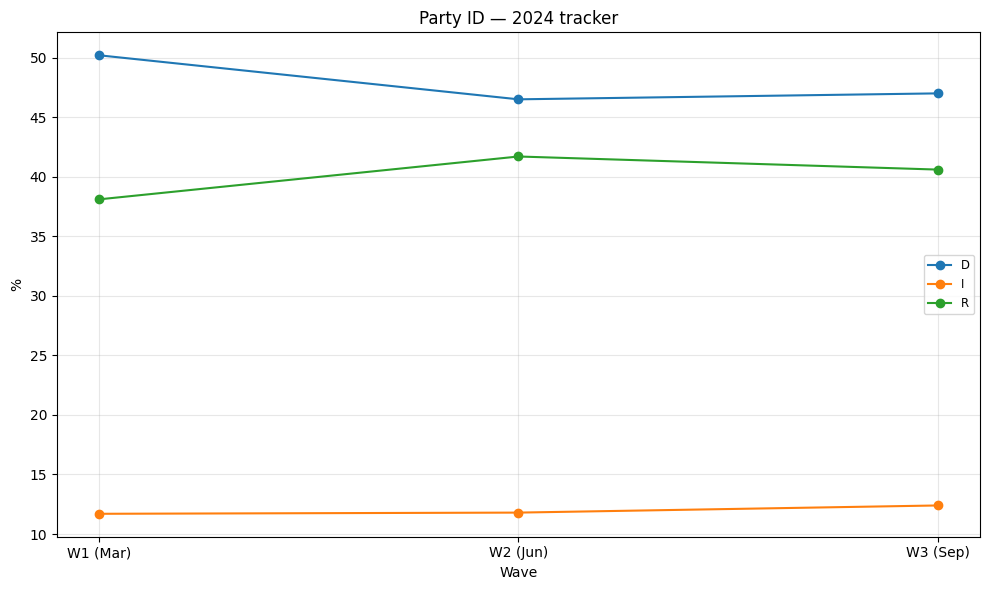

In [5]:
from siege_utilities.reporting.wave_charts import trend_chart, heatmap

fig_trend = trend_chart(long_chain, title='Party ID — 2024 tracker', ylabel='%')
fig_trend

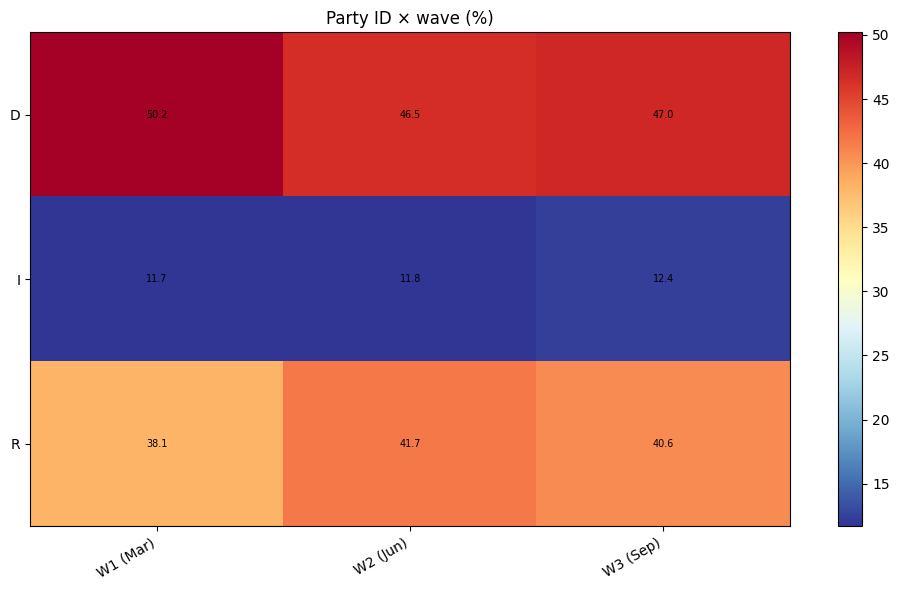

In [6]:
fig_heat = heatmap(long_chain, title='Party ID × wave (%)')
fig_heat

## 5. Ad-hoc primitive — `compare_waves`

`WaveSet.compare_chain` delegates to `survey.waves.compare_waves`. Calling the primitive directly is useful when you already hold a list of Waves without wrapping them in a WaveSet.

In [7]:
direct = compare_waves(waveset, row_var='party')
direct.to_dataframe()

,W1 (Mar),W2 (Jun),W3 (Sep),Δ (last − first)
party,,,,
D,50.2,46.5,47.0,-3.2
I,11.7,11.8,12.4,0.7
R,38.1,41.7,40.6,2.5


## 6. Error paths (data integrity)

The waves module raises `WavesError` — a typed `ValueError` subclass — when the WaveSet is empty or any Wave is missing its respondent-level DataFrame. This replaces a previous silent-no-op path.


In [8]:
from siege_utilities.survey import WavesError

broken = WaveSet(
    name='missing df',
    waves=[
        Wave(id='W1', date=date(2024, 3, 1), df=df_march),
        Wave(id='W2', date=date(2024, 6, 1)),
    ],
)
try:
    broken.compare_chain(row_var='party')
except WavesError as e:
    print('caught WavesError:', e)

caught WavesError: WaveSet 'missing df' waves missing df: ['W2']. Attach respondent-level DataFrames before calling compare_chain.


## Related

- **Source**: `siege_utilities/survey/` (models, crosstab, render, waves), `siege_utilities/reporting/wave_charts.py`
- **Tests**: `tests/test_survey_crosstab.py`, `tests/test_survey_render.py`, `tests/test_survey_waves.py`, `tests/test_polling_analyzer_deprecation.py`
- **Migration from PollingAnalyzer**: see ELE-2439 deprecation notice; ADR `docs/adr/0006-polling-analyzer-location.md`
